# Dataset setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
!mkdir /content/datasets

In [10]:
# This should take 1-2 minutes
# It unzips the dataset in the runtime's local SSD, so when
# you disconnect, it gets deleted
!unzip -q /content/drive/MyDrive/datasets/celeba.zip -d /content/datasets/

# Data loading

In [12]:
import torch
from pathlib import Path

from torchvision.datasets import CelebA

In [13]:
# Do *not* put `celeba` in the path.
# The dataset class will do that automatically!
data_root = Path("/content/datasets")

In [14]:
celeba = CelebA(root=data_root, split="test", download=False)

In [16]:
# This should be 19,962
len(celeba)

19962

# Metrics

In [17]:
def evaluate_retrieval(
    retrieved_indices: list[int],
    ground_truth_indices: list[int],
    k: int
):
    """
    Evaluate the retrieval performance for a single source image.

    Args:
    ----
        retrieved_indices: list of image IDs predicted by the model,
            ordered by similarity (descending).
        ground_truth_indices: list of valid target IDs from the benchmark JSON.
        k: the cutoff for top-K evaluation (e.g., 1, 5, 10).

    Return:
    ------
        A dictionary containing Recall@K and Precision@K.

    """
    # Isolate the top K predictions
    top_k_retrieved = retrieved_indices[:k]

    # Calculate the intersection between predictions and ground truth
    hits = set(top_k_retrieved).intersection(set(ground_truth_indices))
    num_hits = len(hits)

    # Metrics calculations
    # Recall@K (Hit Rate): 1 if at least one match is found, 0 otherwise
    recall_at_k = 1 if num_hits > 0 else 0

    # Precision@K: Fraction of top K predictions that are correct
    precision_at_k = num_hits / k

    return {
        f"Recall@{k}": recall_at_k,
        f"Precision@{k}": precision_at_k
    }

In [19]:
# --- Example Usage ---
# Suppose the model returns these indices from most to least similar:
predictions = [1, 2, 3, 4, 5]
# And we load this from our JSON for this specific source:
ground_truth = [3, 2, 1]

# Evaluate at K=1 and K=5
print("Results @ 1:", evaluate_retrieval(predictions, ground_truth, k=1))
print("Results @ 5:", evaluate_retrieval(predictions, ground_truth, k=5))

Results @ 1: {'Recall@1': 1, 'Precision@1': 1.0}
Results @ 5: {'Recall@5': 1, 'Precision@5': 0.6}


# Evaluation

In [22]:
import json

In [26]:
annotations_path = Path("/content/drive/MyDrive/datasets/celeba_evaluation.json")

with open(annotations_path, "r") as f:
    annotations = json.load(f)

len(annotations)

14

In [30]:
# `annotations` is a list of queries
# Each query is a dictionary with these keys:
# - `query`: the textual query itself
# - `ground_truth`: a dictionary of images
#
# Each element in `ground_truth` is structured as:
# {
#    idx: list[int]
# }
# `idx` is the source image that you have to use together with the `query`
# `list[int]` is the list of acceptable target images, i.e., the images
# that you should retrieve

print(annotations[0].keys())
print()
print("Query:", annotations[0]["query"])
print("Source images:", len(annotations[0]["ground_truth"].keys()))

dict_keys(['query', 'ground_truth'])

Query: +Smiling
Source images: 4786


Let's test the evaluation function. Let's simulate retrieving data for the first image / query.

In [47]:
print("Nothing retrieved:\n", evaluate_retrieval([], annotations[0]["ground_truth"]["13"], 1))
print()
print("Retrieved only one wrong image:\n", evaluate_retrieval([0], annotations[0]["ground_truth"]["13"], 1))
print()
print("Retrieved 10 correct images:\n", evaluate_retrieval(annotations[0]["ground_truth"]["13"][:10], annotations[0]["ground_truth"]["13"], 1))
print()
# This returns 0 and 0 because top-k is set to 1, and the first 5 images
# (by highest similarity) are incorrect. We need to jump at least to top-6 here!
print("Retrieved 5 correct images and 5 wrong images:\n", evaluate_retrieval([0, 1, 2, 3, 4] + annotations[0]["ground_truth"]["13"][:5], annotations[0]["ground_truth"]["13"], 1))
print("Retrieved 5 correct images and 5 wrong images:\n", evaluate_retrieval([0, 1, 2, 3, 4] + annotations[0]["ground_truth"]["13"][:5], annotations[0]["ground_truth"]["13"], 6))

Nothing retrieved:
 {'Recall@1': 0, 'Precision@1': 0.0}

Retrieved only one wrong image:
 {'Recall@1': 0, 'Precision@1': 0.0}

Retrieved 10 correct images:
 {'Recall@1': 1, 'Precision@1': 1.0}

Retrieved 5 correct images and 5 wrong images:
 {'Recall@1': 0, 'Precision@1': 0.0}
Retrieved 5 correct images and 5 wrong images:
 {'Recall@6': 1, 'Precision@6': 0.16666666666666666}


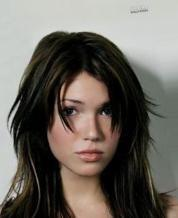

In [53]:
# This is our source image
# Basically, the `key` in the provided JSON corresponds to the
# image index. Note, however, that the key is in string format,
# so remember to convert it with `int(key)`!
celeba[13][0]

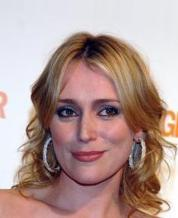

In [54]:
# This is one of the accepted matches
celeba[annotations[0]["ground_truth"]["13"][0]][0]

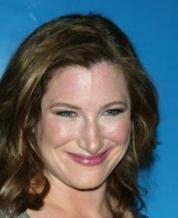

In [56]:
# This is another one of the accepted matches
celeba[annotations[0]["ground_truth"]["13"][1]][0]

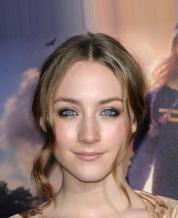

In [57]:
# And yet another one of the accepted matches
celeba[annotations[0]["ground_truth"]["13"][2]][0]

As you can see, all these images are pretty similar to the first one (the "source").
This is exactly what we want.
We constructed the ground truth by taking images that match the given query, with a Hamming distance of at most 2 from the source (i.e., having a perfect match for the query is impossible, so we allow some small variability on other attributes, too).

# Misc

In [20]:
# Assign a unique index to each attribute, and get the inverse mapping
idx2attribute = {idx: name for idx, name in enumerate(celeba.attr_names)}
attribute2idx = {name: idx for idx, name in enumerate(celeba.attr_names)}